In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from heston.closed import heston_call_price
from black_scholes.bs import black_scholes

from neural_network.config import ModelConfig, HestonParams
from neural_network.trainer import HestonTrainer

In [2]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

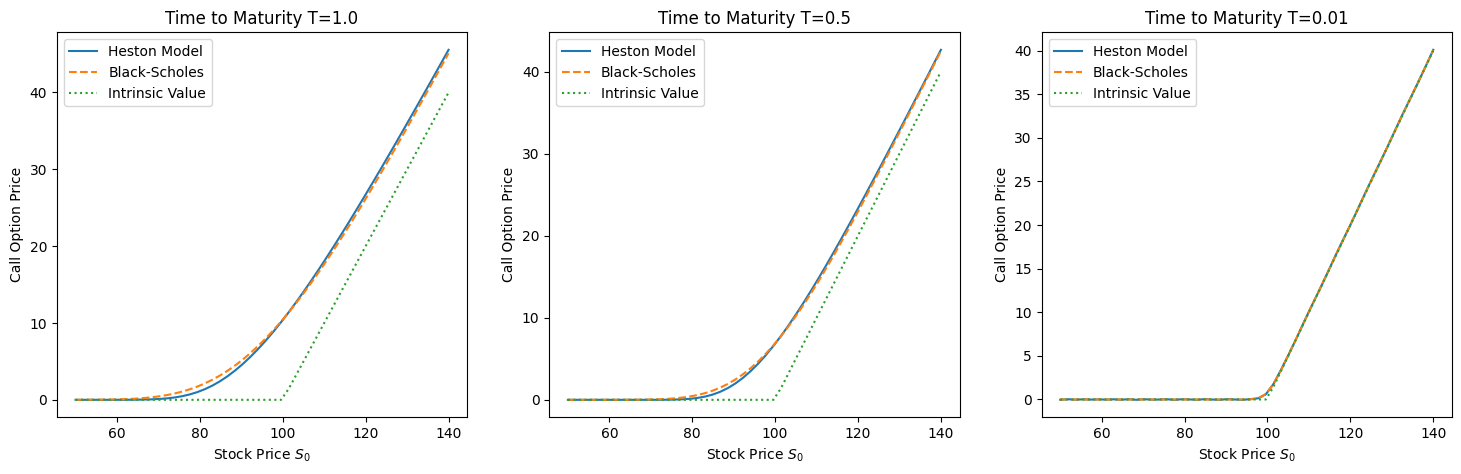

In [3]:
S = np.linspace(50, 140, 50)
intrinsic_values = np.maximum(S - K, 0)

Ts = [1.0, 0.5, 0.01]

plt.figure(figsize=(18, 5))
for i, T in enumerate(Ts):
    prices = [heston_call_price(S0, K, T, r, kappa, theta, sigma, rho, v0) for S0 in S]
    bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T, 'call') for S0 in S]
    plt.subplot(1, 3, i+1)
    plt.plot(S, prices, label='Heston Model')
    plt.plot(S, bs_prices, label='Black-Scholes', linestyle='--')
    plt.plot(S, intrinsic_values, label='Intrinsic Value', linestyle=':')
    plt.title(f'Time to Maturity T={T}')
    plt.xlabel('Stock Price $S_0$')
    plt.ylabel('Call Option Price')
    plt.legend()
plt.show()

In [4]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

S_max = 3 * S0
V_max = 0.5

params = HestonParams(
    S0=S0, v0=v0, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho, T=T, K=K,
    S_max=S_max, V_max=V_max
)

model_config = ModelConfig(
    input_size=3,
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-4
)

loss_weights = {
    'pde': 5000.0,
    'payoff': 0.5,
    'S_min': 10.0,
    'S_max': 0.1,
    'V_min': 1000.0,
    'V_max': 0.03
}

heston_trainer = HestonTrainer(model_config=model_config, heston_params=params, payoff=None, loss_weights=loss_weights, seed=42)

Iteration 0, Loss: 1.3982512950897217
Iteration 100, Loss: 0.6169826984405518
Iteration 200, Loss: 0.3658914566040039
Iteration 300, Loss: 0.1950223296880722
Iteration 400, Loss: 0.1130116656422615
Iteration 500, Loss: 0.09559663385152817
Iteration 600, Loss: 0.08633403480052948
Iteration 700, Loss: 0.07730422914028168
Iteration 800, Loss: 0.06818978488445282
Iteration 900, Loss: 0.05818682909011841
Iteration 1000, Loss: 0.05011696740984917
Iteration 1100, Loss: 0.04078309237957001
Iteration 1200, Loss: 0.03379997983574867
Iteration 1300, Loss: 0.02874508500099182
Iteration 1400, Loss: 0.026128973811864853
Iteration 1500, Loss: 0.024506449699401855
Iteration 1600, Loss: 0.023644475266337395
Iteration 1700, Loss: 0.02357669174671173
Iteration 1800, Loss: 0.02253153547644615
Iteration 1900, Loss: 0.023552656173706055
Iteration 2000, Loss: 0.022900335490703583
Iteration 2100, Loss: 0.022632278501987457
Iteration 2200, Loss: 0.02203131467103958
Iteration 2300, Loss: 0.022547289729118347
It

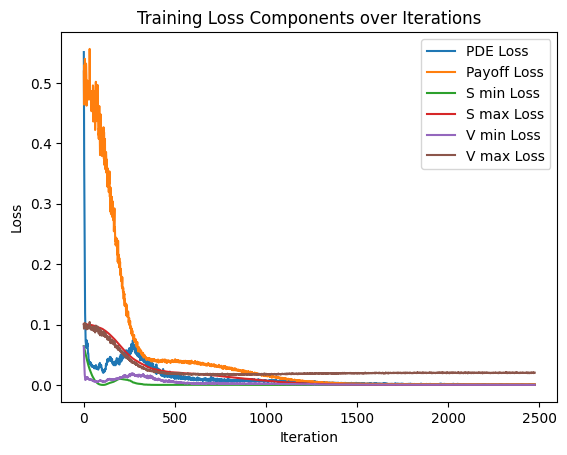

In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-6)
heston_trainer.plot_losses_detailed()

In [8]:
# grid resolution
num_S = 80
num_V = 80

Ss = np.linspace(0.01, S_max, num_S)
Vs = np.linspace(0, V_max, num_V)
t = 0

nn_prices = np.zeros((num_V, num_S))
cf_prices = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = heston_trainer.predict(t, s_val, v_val).item()
        cf_prices[i, j] = heston_call_price(s_val, K, T - t, r, kappa, theta, sigma, rho, v_val)

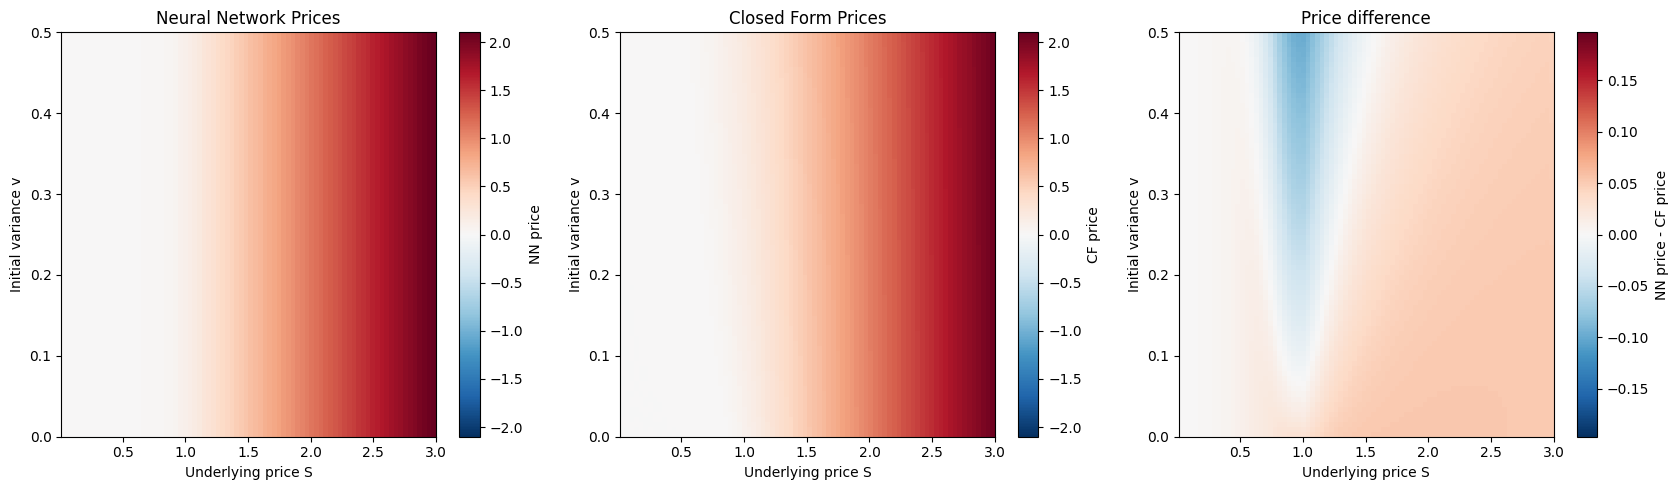

In [9]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(cf_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Closed Form Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - cf_prices
vmax = np.abs(diff).max()*2
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Price difference')
plt.tight_layout()
plt.show()